# Cityscapes sanity check — mixed preprocessing pipeline

This notebook validates the same preprocessing convention used in the updated benchmark:

- **SegFormer / Mask2Former** use `input_source: raw`, i.e. RGB tensors in `[0,1]`, and keep the HuggingFace processor path.
- **DeepLabV3+ / PIDNet / DDRNet** use `input_source: repo`, i.e. RGB tensors normalized with ImageNet mean/std in the dataset, and use `input_norm: none` inside the adapter.

The goal is to verify that the model loading and preprocessing are correct before running the GTA photometric robustness benchmark.


In [1]:
from pathlib import Path

CONFIG_PATH = Path("./cityscapes_sanity_mixed_loader_config.yaml")
assert CONFIG_PATH.exists(), f"Config not found: {CONFIG_PATH}"
print("Using config:", CONFIG_PATH.resolve())


Using config: /home/ace/Downloads/notebooks/repo_similar/sanity_check_cityscapes/cityscapes_sanity_mixed_loader_config.yaml


In [2]:
import os
import sys
import json
import random
from typing import Any, Dict, List
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import matplotlib.pyplot as plt

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

for p in [
    "/home/ace/Downloads",
    "/home/ace/Downloads/PIDNet",
    "/home/ace/Downloads/pytorch-semseg",
    "/home/ace/Downloads/DeepLabV3PlusPytorch",
    "/home/ace/Downloads/DDRNet",
    "/home/ace/Downloads/DDRNet/segmentation",
]:
    if p not in sys.path:
        sys.path.append(p)

from benchmark_models_mixed_loader import (
    build_adapter_from_spec,
    resolve_model_spec_from_key,
)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})


/home/ace/miniconda3/envs/Benchmarking_framework_GTAV/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

CITYSCAPES_ROOT = cfg["cityscapes_root"]
SAVE_DIR = Path(cfg["save_dir"])
DEVICE = torch.device(cfg.get("device", "cuda" if torch.cuda.is_available() else "cpu"))
BATCH_SIZE = int(cfg.get("batch_size", 1))
NUM_WORKERS = int(cfg.get("num_workers", 4))
MAX_SAMPLES = cfg.get("max_samples", None)
SAVE_QUALITATIVE = bool(cfg.get("save_qualitative", True))
N_QUALITATIVE = int(cfg.get("n_qualitative", 3))

SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Save dir:", SAVE_DIR.resolve())
print("Max samples:", MAX_SAMPLES)


Device: cuda
Save dir: /home/ace/Downloads/notebooks/repo_similar/sanity_check_cityscapes/cityscapes_sanity_mixed_loader
Max samples: None


In [4]:
# ==========================================================
# Cityscapes label mapping
# ==========================================================

IGNORE_INDEX = 255
NUM_CLASSES = 19

LABELID_TO_TRAINID = np.full((256,), IGNORE_INDEX, dtype=np.uint8)

_mapping = {
    7: 0,    # road
    8: 1,    # sidewalk
    11: 2,   # building
    12: 3,   # wall
    13: 4,   # fence
    17: 5,   # pole
    19: 6,   # traffic light
    20: 7,   # traffic sign
    21: 8,   # vegetation
    22: 9,   # terrain
    23: 10,  # sky
    24: 11,  # person
    25: 12,  # rider
    26: 13,  # car
    27: 14,  # truck
    28: 15,  # bus
    31: 16,  # train
    32: 17,  # motorcycle
    33: 18,  # bicycle
}

for k, v in _mapping.items():
    LABELID_TO_TRAINID[k] = v

CITYSCAPES_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"
]

CITYSCAPES_COLORS = np.array([
    [128, 64,128],
    [244, 35,232],
    [ 70, 70, 70],
    [102,102,156],
    [190,153,153],
    [153,153,153],
    [250,170, 30],
    [220,220,  0],
    [107,142, 35],
    [152,251,152],
    [ 70,130,180],
    [220, 20, 60],
    [255,  0,  0],
    [  0,  0,142],
    [  0,  0, 70],
    [  0, 60,100],
    [  0, 80,100],
    [  0,  0,230],
    [119, 11, 32],
], dtype=np.uint8)

def colorize(mask):
    return CITYSCAPES_COLORS[mask]


In [5]:
# ==========================================================
# Dataset with both raw and repo-preprocessed inputs
# ==========================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class CityscapesValMixedDataset(Dataset):
    '''
    Returns:
      image_raw:  RGB tensor in [0,1], for HF models
      image_repo: RGB tensor normalized with ImageNet mean/std, for local repo models
      target:     Cityscapes trainIds
    '''
    def __init__(self, root: str, max_samples=None):
        self.root = root

        self.raw_transform = transforms.ToTensor()
        self.repo_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

        self.samples = self._collect_samples()

        if max_samples is not None:
            self.samples = self.samples[:int(max_samples)]

    def _collect_samples(self):
        img_root = os.path.join(self.root, "leftImg8bit", "val")
        gt_root = os.path.join(self.root, "gtFine", "val")

        if not os.path.isdir(img_root):
            raise RuntimeError(f"Cityscapes image root not found: {img_root}")

        if not os.path.isdir(gt_root):
            raise RuntimeError(f"Cityscapes label root not found: {gt_root}")

        samples = []

        for city in sorted(os.listdir(img_root)):
            city_img_dir = os.path.join(img_root, city)
            city_gt_dir = os.path.join(gt_root, city)

            if not os.path.isdir(city_img_dir):
                continue

            for fname in sorted(os.listdir(city_img_dir)):
                if not fname.endswith("_leftImg8bit.png"):
                    continue

                img_path = os.path.join(city_img_dir, fname)
                gt_name = fname.replace("_leftImg8bit.png", "_gtFine_labelIds.png")
                gt_path = os.path.join(city_gt_dir, gt_name)

                if os.path.isfile(gt_path):
                    samples.append((img_path, gt_path))

        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, gt_path = self.samples[idx]

        img = Image.open(img_path).convert("RGB")
        gt = np.array(Image.open(gt_path), dtype=np.uint8)
        gt_train = LABELID_TO_TRAINID[gt]

        return {
            "image_raw": self.raw_transform(img),
            "image_repo": self.repo_transform(img),
            "target": torch.from_numpy(gt_train.astype(np.int64)),
            "image_path": img_path,
            "target_path": gt_path,
        }


In [6]:
# ==========================================================
# Metrics
# ==========================================================

def confusion_matrix_from_preds(pred, target, num_classes=19, ignore_index=255):
    pred = pred.view(-1)
    target = target.view(-1)

    valid = (target != ignore_index) & (target >= 0) & (target < num_classes)
    pred = pred[valid]
    target = target[valid]

    valid_pred = (pred >= 0) & (pred < num_classes)
    pred = pred[valid_pred]
    target = target[valid_pred]

    idx = target * num_classes + pred

    cm = torch.bincount(
        idx,
        minlength=num_classes * num_classes
    ).reshape(num_classes, num_classes)

    return cm


def iou_from_confusion(cm, eps=1e-9):
    tp = torch.diag(cm).float()
    fp = cm.sum(dim=0).float() - tp
    fn = cm.sum(dim=1).float() - tp

    denom = tp + fp + fn

    iou = tp / (denom + eps)
    valid = denom > 0

    miou = iou[valid].mean().item() if valid.any() else float("nan")

    return iou, miou, valid


In [7]:
# ==========================================================
# Build adapters while preserving input_source metadata
# ==========================================================

def normalize_model_config_with_source(models_cfg):
    out = []

    for item in models_cfg.get("enabled", []):

        if isinstance(item, str):
            spec = resolve_model_spec_from_key(item)
            spec["input_source"] = "raw" if spec["type"] in {"segformer", "mask2former"} else "repo"
            out.append(spec)

        elif isinstance(item, dict):

            if "key" in item:
                spec = resolve_model_spec_from_key(item["key"])
                spec.update({k: v for k, v in item.items() if k != "key"})

                if "input_source" not in spec:
                    spec["input_source"] = "raw" if spec["type"] in {"segformer", "mask2former"} else "repo"

                out.append(spec)

            else:
                spec = dict(item)

                if "input_source" not in spec:
                    spec["input_source"] = "raw" if spec["type"] in {"segformer", "mask2former"} else "repo"

                out.append(spec)

        else:
            raise TypeError("Each entry in models.enabled must be a string or dict.")

    return out


def build_adapters_with_specs(models_cfg, device):
    specs = normalize_model_config_with_source(models_cfg)
    out = []

    for spec in specs:
        adapter = build_adapter_from_spec(spec, device)
        out.append((adapter, spec))

    return out


def select_image_tensor(batch, input_source):
    input_source = str(input_source).lower()

    if input_source == "raw":
        return batch["image_raw"]

    if input_source in {"repo", "imagenet", "repo_imagenet"}:
        return batch["image_repo"]

    raise ValueError(f"Unsupported input_source: {input_source}")


In [8]:
# ==========================================================
# Validation
# ==========================================================

@torch.no_grad()
def validate_models():
    ds = CityscapesValMixedDataset(CITYSCAPES_ROOT, max_samples=MAX_SAMPLES)

    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    print(f"Cityscapes val samples: {len(ds)}")

    adapter_specs = build_adapters_with_specs(cfg["models"], DEVICE)

    summary_rows = []
    per_class_rows = []

    qualitative_saved = {adp.name: 0 for adp, _ in adapter_specs}
    qual_dir = SAVE_DIR / "qualitative"
    qual_dir.mkdir(parents=True, exist_ok=True)

    for adp, spec in adapter_specs:

        print(f"\n[eval] {adp.name} | input_source={spec.get('input_source')} | input_norm={getattr(adp, 'input_norm', 'processor')}")

        cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)

        for batch in tqdm(loader, desc=adp.name):

            images = select_image_tensor(batch, spec.get("input_source", "raw")).to(
                DEVICE,
                non_blocking=True
            )

            targets = batch["target"]

            preds, conf = adp.predict(images)
            preds = preds.detach().cpu()

            if preds.shape[-2:] != targets.shape[-2:]:
                preds = F.interpolate(
                    preds.unsqueeze(1).float(),
                    size=targets.shape[-2:],
                    mode="nearest"
                ).squeeze(1).to(torch.int64)

            for i in range(preds.shape[0]):
                cm = confusion_matrix_from_preds(
                    pred=preds[i],
                    target=targets[i],
                    num_classes=NUM_CLASSES,
                    ignore_index=IGNORE_INDEX,
                )

                cm_total += cm

                if SAVE_QUALITATIVE and qualitative_saved[adp.name] < N_QUALITATIVE:
                    raw_img = batch["image_raw"][i]
                    img_np = (raw_img.numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
                    pred_rgb = colorize(preds[i].numpy())

                    model_slug = adp.name.replace(" ", "_").replace("+", "plus").replace("/", "_")
                    stem = Path(batch["image_path"][i]).stem
                    out_base = qual_dir / f"{model_slug}__{stem}"

                    Image.fromarray(pred_rgb).save(str(out_base) + "_mask.png")

                    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
                    axs[0].imshow(img_np)
                    axs[0].set_title("Input")
                    axs[0].axis("off")

                    axs[1].imshow(pred_rgb)
                    axs[1].set_title(adp.name)
                    axs[1].axis("off")

                    plt.tight_layout()
                    plt.savefig(str(out_base) + "_panel.png", dpi=200, bbox_inches="tight")
                    plt.savefig(str(out_base) + "_panel.pdf", bbox_inches="tight")
                    plt.close(fig)

                    qualitative_saved[adp.name] += 1

        iou_k, miou, valid = iou_from_confusion(cm_total)

        summary_rows.append({
            "model": adp.name,
            "input_source": spec.get("input_source"),
            "input_norm": getattr(adp, "input_norm", "processor"),
            "mIoU": float(miou),
            "num_samples": len(ds),
        })

        for k in range(NUM_CLASSES):
            per_class_rows.append({
                "model": adp.name,
                "input_source": spec.get("input_source"),
                "input_norm": getattr(adp, "input_norm", "processor"),
                "class_id": k,
                "class_name": CITYSCAPES_CLASS_NAMES[k],
                "IoU": float(iou_k[k].item()),
                "valid": bool(valid[k].item()),
            })

        print(f"[result] {adp.name}: mIoU = {miou:.4f}")

    df_summary = pd.DataFrame(summary_rows).sort_values("mIoU", ascending=False)
    df_per_class = pd.DataFrame(per_class_rows)

    df_summary.to_csv(SAVE_DIR / "cityscapes_val_summary_mixed_loader.csv", index=False)
    df_per_class.to_csv(SAVE_DIR / "cityscapes_val_per_class_iou_mixed_loader.csv", index=False)

    with open(SAVE_DIR / "cityscapes_sanity_config_resolved.json", "w") as f:
        json.dump(cfg, f, indent=2)

    return df_summary, df_per_class


In [9]:
df_summary, df_per_class = validate_models()

print("\nTop results:")
print(df_summary.to_string(index=False))

df_summary


Cityscapes val samples: 500


/home/ace/miniconda3/envs/Benchmarking_framework_GTAV/lib/python3.13/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


[info] DDRNet official loaded tensors: 333

[eval] SegFormer-B5 | input_source=raw | input_norm=processor


SegFormer-B5: 100%|██████████████████████████████████████████████| 500/500 [02:18<00:00,  3.62it/s]


[result] SegFormer-B5: mIoU = 0.7665

[eval] DeepLabV3+-R101 | input_source=repo | input_norm=none


...

PIDNet-M: 100%|██████████████████████████████████████████████████| 500/500 [00:25<00:00, 19.40it/s]


[result] PIDNet-M: mIoU = 0.7650

[eval] DDRNet-23 | input_source=repo | input_norm=none


DDRNet-23: 100%|█████████████████████████████████████████████████| 500/500 [00:24<00:00, 20.32it/s]

[result] DDRNet-23: mIoU = 0.7951

Top results:
          model input_source input_norm     mIoU  num_samples
      DDRNet-23         repo       none 0.795102          500
   SegFormer-B5          raw  processor 0.766506          500
       PIDNet-M         repo       none 0.764958          500
DeepLabV3+-R101         repo       none 0.762102          500


,model,input_source,input_norm,mIoU,num_samples
3,DDRNet-23,repo,none,0.795102,500
0,SegFormer-B5,raw,processor,0.766506,500
2,PIDNet-M,repo,none,0.764958,500
1,DeepLabV3+-R101,repo,none,0.762102,500


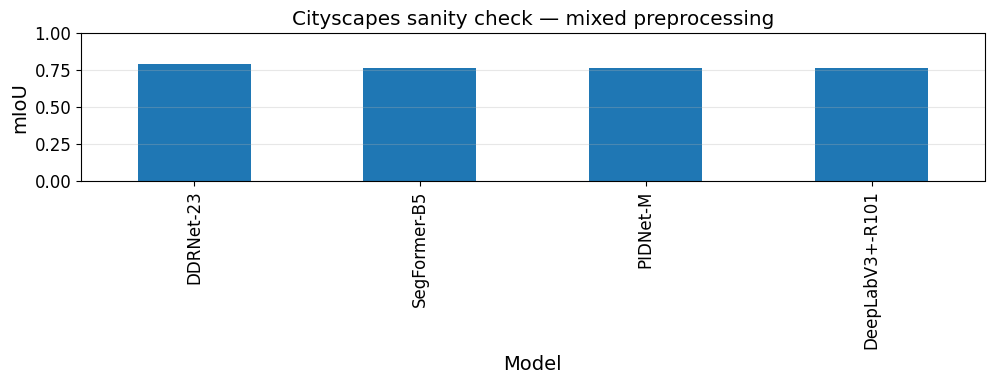

In [10]:
# Optional barplot

ax = df_summary.sort_values("mIoU", ascending=False).plot(
    x="model",
    y="mIoU",
    kind="bar",
    figsize=(10, 4),
    legend=False,
)

ax.set_ylim(0, 1)
ax.set_ylabel("mIoU")
ax.set_xlabel("Model")
ax.set_title("Cityscapes sanity check — mixed preprocessing")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / "cityscapes_sanity_miou_mixed_loader.pdf", bbox_inches="tight")
plt.savefig(SAVE_DIR / "cityscapes_sanity_miou_mixed_loader.png", dpi=300, bbox_inches="tight")
plt.show()
